# TITLE: ONLINE SHOPPERS INTENTION

The aim is to predict if a customer made a purchase or not using this dataset [kaggle]("https://www.kaggle.com/datasets/henrysue/online-shoppers-intention")



## PROBLEM STATEMENT
For any e-commerce platform, high traffic doesn’t necessarily mean high sales. Most people will surf and leave without buying.
The goal of this project is to predict whether a user session will result in a purchase based on browsing behavior.

This helps businesses identify high-intent customers and improve conversion rates.


## OBJECTIVES
- To analyze the distribution of purchase and non-purchase sessions in the dataset.
- To examine how bounce rates and exit rates influence purchasing behavior.
- To examine relationship between product-related page visits, PageValues, and purchasing behavior.
- To analyze the impact of visitor type on purchasing.


## VARIABLES
* Administrative → number of admin pages visited (login, account stuff)
* Administrative_Duration → time spent there
* Informational → pages like “about us”, help, etc.
* Informational_Duration → time spent there
* ProductRelated → number of product pages visited (THIS IS IMPORTANT)
* ProductRelated_Duration → time spent on product pages (VERY IMPORTANT)
* BounceRates → % of people who leave instantly(high = bad)
* ExitRates → % of exits from pages(also bad if high)
* PageValues → how valuable pages are (higher = closer to purchase)
* SpecialDay → closeness to events (like holidays)
* Month → when the session happened
* Weekend → weekend or not
* OperatingSystems
* Browser
* Region
* TrafficType
* VisitorType

    Returning_Visitor → VERY important
    
    New_Visitor → less likely to buy
* Revenue

    TRUE → user bought something

    FALSE → user wasted everyone’s time

## IMPORT LIBRARIES

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## LOAD DATASET


In [2]:
df=pd.read_csv("online_shoppers_intention.csv")

## DATASET UNDERSTANDING

In [3]:
#view first rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
#no. of rows and columns
df.shape

(12330, 18)

In [5]:
#check stucture of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [6]:
#summary statistics
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [7]:
#check datatypes
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [8]:
#check no.of purchases and non purchases made
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [9]:
#bounce rates analysis for buyers and non buyers
df.groupby("Revenue")["BounceRates"].mean()

Revenue
False    0.025317
True     0.005117
Name: BounceRates, dtype: float64

In [10]:
#exit rate analysis
df.groupby("Revenue")["ExitRates"].mean()

Revenue
False    0.047378
True     0.019555
Name: ExitRates, dtype: float64

In [11]:
#product related page visits between buyers and non buyers
df.groupby("Revenue")["ProductRelated"].mean()

Revenue
False    28.714642
True     48.210168
Name: ProductRelated, dtype: float64

In [12]:
#time spent on product pages
df.groupby("Revenue")["ProductRelated_Duration"].mean()

Revenue
False    1069.987809
True     1876.209615
Name: ProductRelated_Duration, dtype: float64

In [13]:
#visitor type analysis-visitor type that purchases more
pd.crosstab(df["VisitorType"], df["Revenue"])


Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


In [14]:
#weekend purchase analysis
pd.crosstab(df["Weekend"], df["Revenue"])


Revenue,False,True
Weekend,,
False,8053,1409
True,2369,499


In [15]:

#monthly purchase
pd.crosstab(df["Month"], df["Revenue"])

Revenue,False,True
Month,,
Aug,357,76
Dec,1511,216
Feb,181,3
Jul,366,66
June,259,29
Mar,1715,192
May,2999,365
Nov,2238,760
Oct,434,115


## DATA CLEANING

In [16]:
#check missing values
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [17]:
#check duplicates
df.duplicated().sum()

np.int64(125)

In [18]:
#remove duplicates
df.drop_duplicates()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [19]:
#cleaned dataset
df.to_csv("cleaned_online_shoppers_intention.csv", index=False)

## EXPLORATORY DATA ANALYSIS

### PURCHASE DISTRIBTION

Text(0.5, 1.0, 'Purchase Distribution')

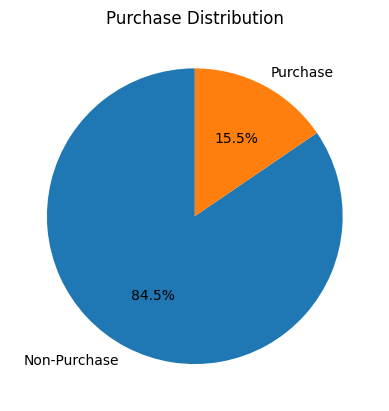

In [20]:
# Revenue distribution using pie chart

purchase_counts = df["Revenue"].value_counts()

plt.pie(
    purchase_counts,
    labels=["Non-Purchase", "Purchase"],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Purchase Distribution")

## OBSERVATION
- Majority of the visitors browse the website but end up not purchasing anything.
- Few users end up making a purchase

### BOUNCE RATES VS REVENUE

Text(0.5, 1.0, 'Bounce Rate vs Purchase')

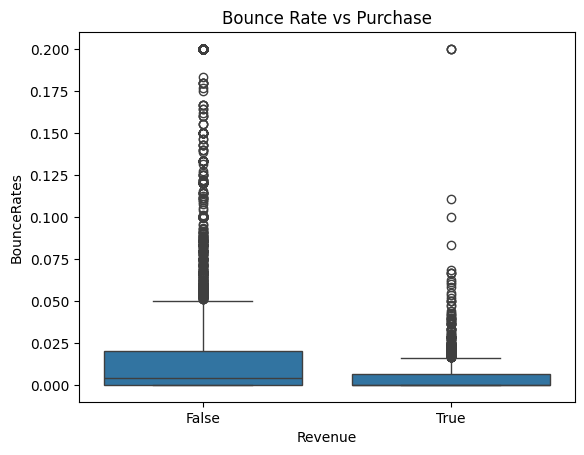

In [21]:
sns.boxplot(x="Revenue", y="BounceRates", data=df)
plt.title("Bounce Rate vs Purchase")

## OBSERVATION
- Non-buyers show higher bounce rates compared to buyers.
- The high bounce rates results to low probability of making a purchase.

### EXIT RATES VS REVENUE

Text(0.5, 1.0, 'Exit Rate vs Purchase')

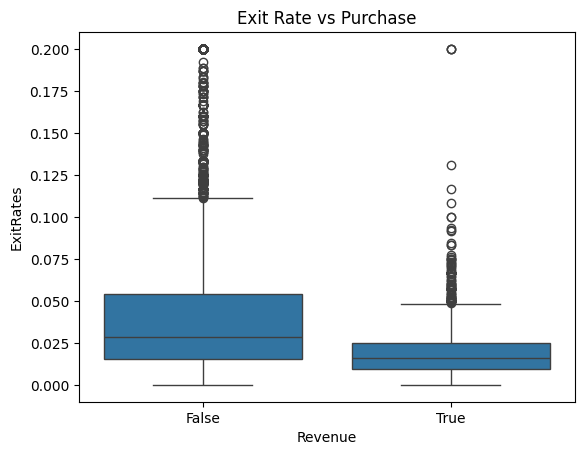

In [22]:
sns.boxplot(x="Revenue", y="ExitRates", data=df)
plt.title("Exit Rate vs Purchase")


## OBSERVATION
- Users that made a purchase have lower exit rates while non buyers have high exit rates.
- Lower exit rates results to successful purchase.

### PRODUCT-RELATED PAGE ANALYSIS

Text(0.5, 1.0, 'Product Page Visits vs Purchase')

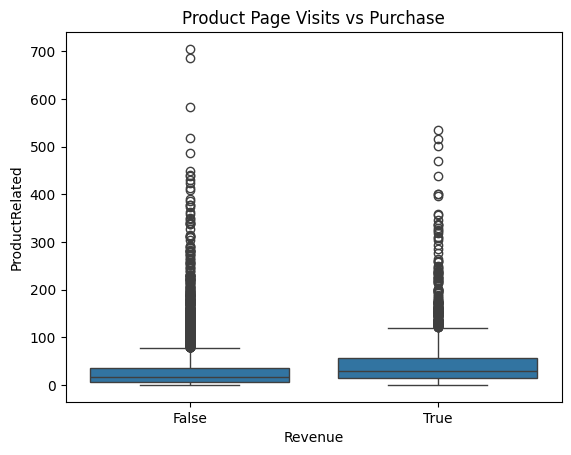

In [23]:
sns.boxplot(x="Revenue", y="ProductRelated", data=df)
plt.title("Product Page Visits vs Purchase")


## OBSERVATION
- Buyers visited more product-related pages than non-buyers.
- High product page visits indicates probability of purchasing a product. 

### PAGE VALUES VS REVENUE

Text(0, 0.5, 'PageValues')

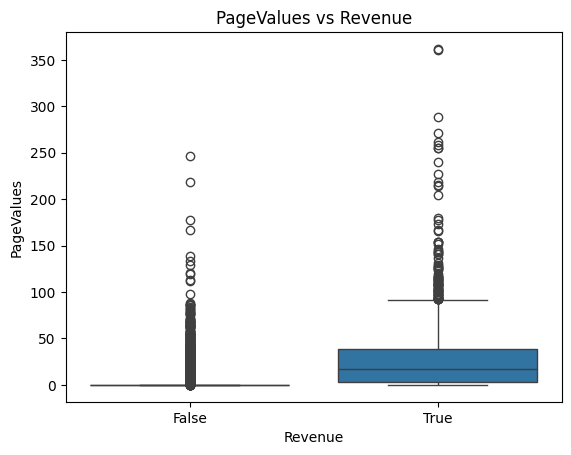

In [24]:
# Create boxplot
sns.boxplot(x="Revenue", y="PageValues", data=df)

# Add title and labels
plt.title("PageValues vs Revenue")
plt.xlabel("Revenue")
plt.ylabel("PageValues")


## OBSERVATION
- Buyers have higher page values than non buyers.
- Higher page values indicates the likelihood of a buyer purchasing.

### TIME SPENT ON PRODUCT PAGES

Text(0, 0.5, 'Revenue')

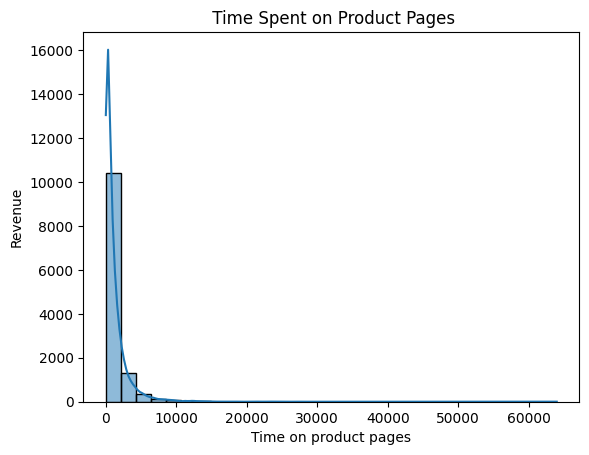

In [25]:
#Compare time spent on product pages vs Revenue
sns.histplot(df["ProductRelated_Duration"], bins=30, kde=True)

plt.title(" Time Spent on Product Pages")
plt.xlabel("Time on product pages")
plt.ylabel("Revenue")


## OBSERVATION
- Most users spend a short amount of time on product pages.
- Few users spend longer time on product pages.

### WEEKEND PURCHASE ANALYSIS

Text(0, 0.5, 'Revenue')

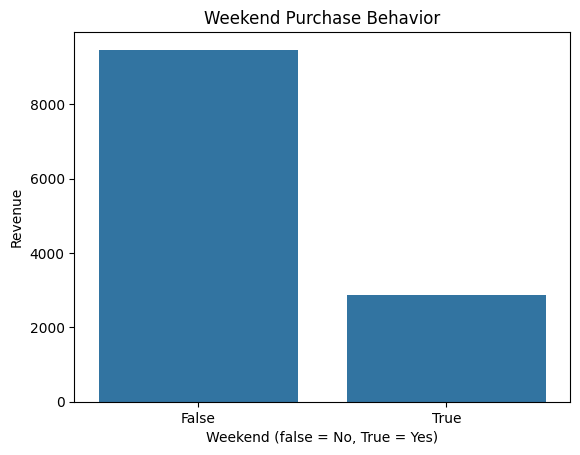

In [26]:

#create countplot
sns.countplot(x="Weekend", data=df)

plt.title("Weekend Purchase Behavior")
plt.xlabel("Weekend (false = No, True = Yes)")
plt.ylabel("Revenue")

## OBSERVATION
- Customers made less purchases on weekend.
- More purchases were made on weekdays.

### CORRELATION ANALYSIS

Text(0.5, 1.0, 'Correlation Heatmap')

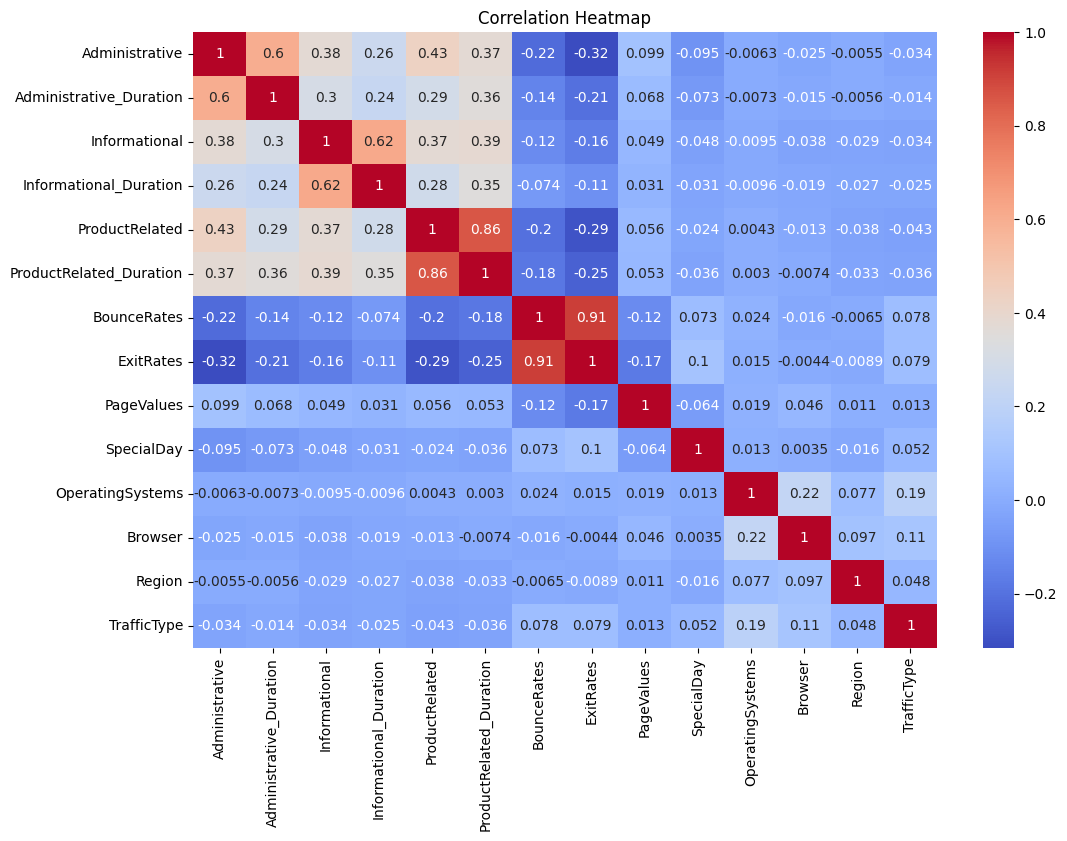

In [27]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

## OBSERVATON
-  users who visit more product pages tend to spend more time on them.

- BounceRates and ExitRates are correlated,in that users who leave quickly are also more likely to exit the website.


## FINAL INSIGHTS
-  Bounce Rates and Exit Rates are higher among non-buyers, showing that early exit reduce purchasing chances.
-  Returning visitors buy more often than new visitors, which shows that trust and familiarity increase purchases. 
- PageValues is very important because higher values usually mean the user is more likely to buy.  
- Buyers tend to visit more product-related pages, showing that deeper browsing increases purchase chances.